# SFO 1-Hour and 12-Hour Flight Delay Baseline Model

In [107]:
#libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import ensemble
from sklearn.ensemble import RandomForestClassifier

import os

In [2]:
print(os.getcwd())

/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/Baseline_Model


## Load data

This will be using the new parquet files into two and four dataframes

In [20]:
# new data load with parquet files, below loads will no longer be used
# renaming dataframe with a *_p_* to indicate the parquet file was used
two_p_df = pd.read_parquet("../datasets/sfo_delay_features_2h.parquet")
four_p_df = pd.read_parquet("../datasets/sfo_delay_features_4h.parquet")

print("2hr shape:", two_p_df.shape)
print("4hr shape:", four_p_df.shape)
print("\n2hr columns:\n", two_p_df.columns.tolist())
print("\n4hr columns:\n", four_p_df.columns.tolist())

2hr shape: (454748, 183)
4hr shape: (454748, 183)

2hr columns:
 ['flight_id', 'flight_date', 'scheduled_dep_utc', 'prediction_cutoff_utc', 'reporting_airline', 'dest', 'prediction_horizon_hours', 'dep_delay_minutes', 'cancelled', 'target_cancelled', 'target_delay_ge_15', 'target_delay_bin', 'target_delay_bin_label', 'eda_only_carrier_delay_minutes', 'eda_only_weather_delay_minutes', 'eda_only_nas_delay_minutes', 'eda_only_security_delay_minutes', 'eda_only_late_aircraft_delay_minutes', 'day_of_week', 'scheduled_dep_hour', 'scheduled_arr_hour', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'days_until_holiday', 'days_since_holiday', 'scheduled_sfo_departures_same_hour', 'scheduled_carrier_departures_same_hour', 'distance_miles', 'scheduled_elapsed_minutes', 'hist_carrier_90d_total_count', 'hist_carrier_90d_operated_count', 'hist_carrier_90d_cancel_rate', 'hist_carrier_90d_delay_ge_15_rate', 'hist_carrier_90d_delay_ge_60_rate', 'hist_carrier_90d_delay_ge_120_r

In [21]:
print("2hr file - unique prediction_horizon_hours:", two_p_df["prediction_horizon_hours"].unique())
print("4hr file - unique prediction_horizon_hours:", four_p_df["prediction_horizon_hours"].unique())

# check if the two dataframes are literally identical
print("\nAre the two files identical?", two_p_df.equals(four_p_df))

2hr file - unique prediction_horizon_hours: [2]
4hr file - unique prediction_horizon_hours: [4]

Are the two files identical? False


In [22]:
# check the new values
print("target_delay_bin unique values:", four_p_df["target_delay_bin"].unique())
print("\ntarget_delay_bin_label unique values:", four_p_df["target_delay_bin_label"].unique())
print("\nMissing values in target_delay_bin:", four_p_df["target_delay_bin"].isnull().sum())

target_delay_bin unique values: <IntegerArray>
[<NA>, 0, 2, 1, 3, 4]
Length: 6, dtype: Int8

target_delay_bin_label unique values: <ArrowStringArray>
[               nan,         'under_15',  '60_to_under_120',
   '15_to_under_60', '120_to_under_240',         '240_plus']
Length: 6, dtype: str

Missing values in target_delay_bin: 5361


In [23]:
# are the missing values cancelled flights?
print(four_p_df[four_p_df["target_delay_bin"].isnull()]["cancelled"].value_counts())
print(four_p_df[four_p_df["target_delay_bin"].isnull()]["target_cancelled"].value_counts())

cancelled
1    5361
Name: count, dtype: int64
target_cancelled
1    5361
Name: count, dtype: int64


In [24]:
# create combined target columns for 5 delay categories and a 6th cancelled flight category.
# fill cancelled flights as their own category (5) instead of NA
two_p_df["cl_target_new"] = two_p_df["target_delay_bin"].fillna(5).astype(int)
four_p_df["cl_target_new"] = four_p_df["target_delay_bin"].fillna(5).astype(int)

print("2-hr categories:", sorted(two_p_df["cl_target_new"].unique()))
print("4-hr categories:", sorted(four_p_df["cl_target_new"].unique()))
print("\n2-hr value counts:\n", two_p_df["cl_target_new"].value_counts().sort_index())

2-hr categories: [0, 1, 2, 3, 4, 5]
4-hr categories: [0, 1, 2, 3, 4, 5]

2-hr value counts:
 cl_target_new
0    355831
1     61905
2     19819
3      8931
4      2901
5      5361
Name: count, dtype: int64


## Category 0, flights under 15 minutes delay, repreesent the majority of flight types in this data


In [25]:
print("2-hr category percentages:")
print((two_p_df["cl_target_new"].value_counts(normalize=True) * 100).round(2))

2-hr category percentages:
cl_target_new
0    78.25
1    13.61
2     4.36
3     1.96
5     1.18
4     0.64
Name: proportion, dtype: float64


### selecting 0 as the baseline model would give us 78.25% accuracy, let's see if our models can beat it

## what is the date range of the new parquet 2-hr and 4-hr dataframes?

In [27]:
# check date range for new data
print("2-hr date range:", two_p_df["flight_date"].min(), "to", two_p_df["flight_date"].max())
print("4-hr date range:", four_p_df["flight_date"].min(), "to", four_p_df["flight_date"].max())

2-hr date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00
4-hr date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00


In [28]:
# let's select the features of the parquet file to match the features from Santi
# columns to exclude for features that aren't usable
non_features = {
    "flight_id", "flight_date", "scheduled_dep_utc", "prediction_cutoff_utc",
    "prediction_horizon_hours", "dep_delay_minutes", "cancelled",
    "target_cancelled", "target_delay_ge_15", "target_delay_bin",
    "target_delay_bin_label", "eda_only_carrier_delay_minutes",
    "eda_only_weather_delay_minutes", "eda_only_nas_delay_minutes",
    "eda_only_security_delay_minutes", "eda_only_late_aircraft_delay_minutes",
}

# faa aircraft-spec columns to exclude per Santi's notebook
faa_features = {
    "aircraft_year_manufactured", "aircraft_type_code", "engine_type_code",
    "aircraft_manufacturer", "aircraft_model", "number_of_engines",
    "number_of_seats", "aircraft_weight_class", "aircraft_cruise_speed",
    "engine_thrust", "faa_record_type", "aircraft_age_years", "faa_match_flag",
}

# candidate features for everything else
candidate_features = [col for col in two_p_df.columns if col not in non_features]

# check the missing amounts/percents for each candidate feature
missing_pct = (two_p_df[candidate_features].isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct.head(20))

origin_wind_gust_excess_mps                           90.725633
origin_wind_gust_mps                                  90.725633
origin_wind_gust_max_prior_3h                         78.476211
minutes_since_previous_actual_arrival                 62.732546
previous_arrival_delay_known                          62.732546
origin_precipitation_mm                               41.204579
carrier_destination_departures_delay_mean_6h          41.183689
carrier_destination_departures_delay_ge_15_rate_6h    41.183689
origin_altimeter_hpa                                  24.872017
origin_ceiling_height_m                               19.236368
carrier_sfo_arrivals_delay_ge_15_rate_3h              18.287271
carrier_sfo_arrivals_delay_mean_3h                    18.287271
origin_station_level_pressure_hpa                     14.298908
carrier_sfo_departures_delay_ge_15_rate_3h            13.417101
carrier_sfo_departures_delay_mean_3h                  13.417101
sfo_arrivals_delay_ge_15_rate_1h        

### we are missing a lot of features from origin_wind_gust and wing_gust_excess, keeping everything that has more than 10% features listed

In [37]:
# copy over the build model function from below

def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=1, use_bias=True)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model

In [ ]:
# we need to build the final list of features
# drop columns missing 90% or more of their values. Threshold set by team.
missing_threshold = 90.0
high_missing_features = missing_pct[missing_pct >= missing_threshold].index.tolist()
print("Dropped for high missingness:", high_missing_features)

# final feature list candidate features minus faa features minus high-missing features
final_features_p = [
    col for col in candidate_features
    if col not in faa_features
    and col not in high_missing_features
]

print(f"\nTotal candidate features: {len(candidate_features)}")
print(f"Dropped (FAA): {len(faa_features)}")
print(f"Dropped (high missing): {len(high_missing_features)}")
print(f"Final feature count: {len(final_features_p)}")

Dropped for high missingness: ['origin_wind_gust_excess_mps', 'origin_wind_gust_mps']

Total candidate features: 168
Dropped (FAA): 13
Dropped (high missing): 2
Final feature count: 153


## which features are numeric and which are non-numeric, we have a total of 168 features

In [30]:
# check which final features are numeric vs non-numeric
numeric_features_p = two_p_df[final_features_p].select_dtypes(include="number").columns.tolist()
non_numeric_features_p = [col for col in final_features_p if col not in numeric_features_p]

print(f"Numeric features: {len(numeric_features_p)}")
print(f"Non-numeric features: {len(non_numeric_features_p)}")
print("\nNon-numeric columns:", non_numeric_features_p)

Numeric features: 151
Non-numeric features: 2

Non-numeric columns: ['reporting_airline', 'dest']


In [73]:
# remove the leaked target column from features, this was giving us an almost perfect classification 
numeric_features_p = [col for col in numeric_features_p if col != "cl_target_new"]
print("Corrected numeric feature count:", len(numeric_features_p))

Corrected numeric feature count: 150


### we have two non-numeric features, 'reporting_airline' and 'dest'

## 2-hour regression model

In [74]:
# split 2-hr data into train, val, and test using project config dates
two_p_train_df = two_p_df[(two_p_df["flight_date"] >= "2022-01-01") & (two_p_df["flight_date"] < "2025-01-01")]
two_p_val_df = two_p_df[(two_p_df["flight_date"] >= "2025-01-01") & (two_p_df["flight_date"] < "2026-01-01")]
two_p_test_df = two_p_df[(two_p_df["flight_date"] >= "2026-01-01") & (two_p_df["flight_date"] < "2026-06-01")]

print("2-hr Train:", two_p_train_df.shape, "Validation:", two_p_val_df.shape, "Test:", two_p_test_df.shape)

2-hr Train: (297860, 184) Validation: (110716, 184) Test: (46172, 184)


In [75]:
# define targets
target_p = "dep_delay_minutes" # regression target to predict actual number of minutes a flight delayed
cl_target_p = "cl_target_new" # classification traget to clasiffy 5 delays category

In [76]:
# we need to separate rows where dep_delay_minutes are 'NaN'
# this is interferring with the logistic regression model
# drop rows where regression target is missing
two_p_train_df_reg = two_p_train_df[two_p_train_df[target_p].notna()]
two_p_val_df_reg = two_p_val_df[two_p_val_df[target_p].notna()]
two_p_test_df_reg = two_p_test_df[two_p_test_df[target_p].notna()]

print("2-hr Train wihtout cancellations:", two_p_train_df_reg.shape)
print("2-hr Val without cancellations:", two_p_val_df_reg.shape)
print("2-hr Test  without cancellations:", two_p_test_df_reg.shape)


2-hr Train wihtout cancellations: (293852, 184)
2-hr Val without cancellations: (109996, 184)
2-hr Test  without cancellations: (45661, 184)


In [77]:
# extract features and target for 2-hr regression (cancelled flights excluded)
two_p_X_train = two_p_train_df_reg[numeric_features_p]
two_p_y_train = two_p_train_df_reg[target_p]
two_p_X_val = two_p_val_df_reg[numeric_features_p]
two_p_y_val = two_p_val_df_reg[target_p]
two_p_X_test = two_p_test_df_reg[numeric_features_p]
two_p_y_test = two_p_test_df_reg[target_p]

# impute missing values using median from training data
two_p_imputer = SimpleImputer(strategy="median")
two_p_X_train_imp = two_p_imputer.fit_transform(two_p_X_train)
two_p_X_val_imp = two_p_imputer.transform(two_p_X_val)
two_p_X_test_imp = two_p_imputer.transform(two_p_X_test)

# scale features
two_p_scaler = StandardScaler()
two_p_scaler.fit(two_p_X_train_imp)
two_p_X_train_std = two_p_scaler.transform(two_p_X_train_imp)
two_p_X_val_std = two_p_scaler.transform(two_p_X_val_imp)
two_p_X_test_std = two_p_scaler.transform(two_p_X_test_imp)

### build and train the linear regression model

In [78]:
# build regression model with single dense layer
def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session() # reset model
    tf.random.set_seed(0) # reproducible seed

    # build the model
    model = tf.keras.Sequential([ 
        tf.keras.Input(shape=(num_features,)), # use features for input, define how many
        tf.keras.layers.Dense(units=1, use_bias=True) # output single number
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) # use the Adam optimizer

    # use Adam for weight optimization, MSE for prediction error
    model.compile( 
        optimizer=optimizer,
        loss="mse", # compute loss as mean squared error
        metrics=["mae"] # convert MSE back into minutes
    )

    return model

30 epochs gave better resutls, but it was still learning. Try 60 epochs for the model

In [89]:
# build and train 2-hr regression model
two_p_model = build_model(num_features=two_p_X_train_std.shape[1], learning_rate=0.0001)
two_p_history = two_p_model.fit(
    two_p_X_train_std, two_p_y_train,
    validation_data=(two_p_X_val_std, two_p_y_val),
    epochs=30, batch_size=256
)

Epoch 1/30
   1/1148 ━━━━━━━━━━━━━━━━━━━━ 5:22 281ms/step - loss: 969.9347 - mae: 15.3245

2026-07-26 09:24:23.514332: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2954.7400 - mae: 18.1082 - val_loss: 2628.1272 - val_mae: 17.5296
Epoch 2/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2916.7732 - mae: 17.8506 - val_loss: 2595.9978 - val_mae: 17.3468
Epoch 3/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2889.9316 - mae: 17.8322 - val_loss: 2573.7241 - val_mae: 17.3099
Epoch 4/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2870.0728 - mae: 17.9168 - val_loss: 2557.6775 - val_mae: 17.3407
Epoch 5/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2854.5354 - mae: 18.0245 - val_loss: 2545.5183 - val_mae: 17.3921
Epoch 6/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2841.7178 - mae: 18.1215 - val_loss: 2535.7786 - val_mae: 17.4457
Epoch 7/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2830.6870 - mae: 18.1989 - val_loss: 2527.5630 - val_mae: 17.4950
Epoch 8/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2820.8757 - mae: 18.2582 - val_loss: 2520.3254 - val_

### VAl MAE score val_mae = 17.48 but starts to rise again to 17.80 by epoch 30
### Val Loss keeps decreasing through each epoch starting from start to finish from 2629.7568 to 2322.78
this is showing that the average predictio minutes is off by 17.97, which give about a 20 minutes. This allows users to comfortably arrive in a given timeframe for their flights. Even with the 60-epoch final MAE of 17.9746, the window of delay is very useable for everyday travelers.

In [81]:
print("Missing y_train values:", two_p_y_train.isnull().sum())
print("Missing y_val values:", two_p_y_val.isnull().sum())
print("Missing y_test values:", two_p_y_test.isnull().sum())

Missing y_train values: 0
Missing y_val values: 0
Missing y_test values: 0


# 4-hour Regression Model

In [82]:
# let's split the data for the four hour into train/val/test
four_p_train_df = four_p_df[(four_p_df["flight_date"] >= "2022-01-01") & (four_p_df["flight_date"] < "2025-01-01")]
four_p_val_df = four_p_df[(four_p_df["flight_date"] >= "2025-01-01") & (four_p_df["flight_date"] < "2026-01-01")]
four_p_test_df = four_p_df[(four_p_df["flight_date"] >= "2026-01-01") & (four_p_df["flight_date"] < "2026-06-01")]

# let's make sure the shape of the 4-hour split matches that of the 2-hour
print("4-hr Train:", four_p_train_df.shape, "Validation:", four_p_val_df.shape, "test:", four_p_test_df.shape)
print("2-hr Train:", two_p_train_df.shape, "Validation:", two_p_val_df.shape, "Test:", two_p_test_df.shape)

4-hr Train: (297860, 184) Validation: (110716, 184) test: (46172, 184)
2-hr Train: (297860, 184) Validation: (110716, 184) Test: (46172, 184)


In [83]:
# perform the same cleaning on the 4-hour to dropped cancelled flights which have NaN in the fields
# this is needed for our linear regression model to perform
four_p_train_df_reg = four_p_train_df[four_p_train_df[target_p].notna()]
four_p_val_df_reg = four_p_val_df[four_p_val_df[target_p].notna()]
four_p_test_df_reg = four_p_test_df[four_p_test_df[target_p].notna()]

print("4-hr Train without cancellations:", four_p_train_df_reg.shape)
print("4-hr Val w/o cancellations:", four_p_val_df_reg.shape)
print("4-hr Test w/o cancellations:", four_p_test_df_reg.shape)

4-hr Train without cancellations: (293852, 184)
4-hr Val w/o cancellations: (109996, 184)
4-hr Test w/o cancellations: (45661, 184)


In [84]:
# separate numeric features and target for 4-hur regressions model
four_p_X_train = four_p_train_df_reg[numeric_features_p]
four_p_y_train = four_p_train_df_reg[target_p]
four_p_X_val = four_p_val_df_reg[numeric_features_p]
four_p_y_val = four_p_val_df_reg[target_p]
four_p_X_test = four_p_test_df_reg[numeric_features_p]
four_p_y_test = four_p_test_df_reg[target_p]

# impute missing values using median from training data
four_p_imputer = SimpleImputer(strategy="median") # use the median for the impute calculation
four_p_X_train_imp = four_p_imputer.fit_transform(four_p_X_train) # fit the median training to the train dataset
four_p_X_val_imp = four_p_imputer.transform(four_p_X_val) # fit the median training values to val
four_p_X_test_imp = four_p_imputer.transform(four_p_X_test) # fit the median training values to test

# scale features
four_p_scaler = StandardScaler() # build the scaler
four_p_scaler.fit(four_p_X_train_imp) # use the training imputed data to normalize the dataset
four_p_X_train_std = four_p_scaler.transform(four_p_X_train_imp) # perform normlaization on train
four_p_X_val_std = four_p_scaler.transform(four_p_X_val_imp) # normalziae val
four_p_X_test_std = four_p_scaler.transform(four_p_X_test_imp) # normalize test

In [85]:
# build the 4-hour regression model
four_p_model = build_model(num_features=four_p_X_train_std.shape[1], learning_rate=0.0001)
four_p_history = four_p_model.fit(
    four_p_X_train_std, four_p_y_train,
    validation_data=(four_p_X_val_std, four_p_y_val),
    epochs=30, batch_size=256   # use 60 epochs like in 2-hour model
)

Epoch 1/30
   1/1148 ━━━━━━━━━━━━━━━━━━━━ 4:53 256ms/step - loss: 960.2774 - mae: 15.1438

2026-07-26 09:12:29.523190: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2953.4072 - mae: 18.1139 - val_loss: 2636.8782 - val_mae: 17.5861
Epoch 2/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2926.2034 - mae: 17.9937 - val_loss: 2613.7480 - val_mae: 17.4956
Epoch 3/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2906.5547 - mae: 18.0071 - val_loss: 2597.5449 - val_mae: 17.4813
Epoch 4/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2891.5920 - mae: 18.0718 - val_loss: 2585.6858 - val_mae: 17.4993
Epoch 5/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2879.5681 - mae: 18.1466 - val_loss: 2576.5667 - val_mae: 17.5282
Epoch 6/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2869.4712 - mae: 18.2156 - val_loss: 2569.2207 - val_mae: 17.5615
Epoch 7/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2860.7122 - mae: 18.2758 - val_loss: 2563.0479 - val_mae: 17.5969
Epoch 8/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2852.9395 - mae: 18.3275 - val_loss: 2557.6851 - val_

### Loss and Validation loss continue to decrease through the 30 epoch range from 2953.4072 -> 2760.5859 and 2636.8782 -> 2488.6360.
### val_mae is lowest at 17.48 (minutes) then rises back up to 18.26 by epoch 30

## How do the regression models peform to the test data?

In [92]:
# evaluate the 2-hr and 4-hr regression models on test set
two_p_test_loss, two_p_test_mae = two_p_model.evaluate(two_p_X_test_std, two_p_y_test)
four_p_test_loss, four_p_test_mae = four_p_model.evaluate(four_p_X_test_std, four_p_y_test)

print(f"2-hr Test MAE: {two_p_test_mae:.3f}")
print(f"4-hr Test MAE: {four_p_test_mae:.3f}")

# baseline of predicting the average delay each time
from sklearn.metrics import mean_absolute_error
import numpy as np

two_p_naive_pred = np.full_like(two_p_y_test, two_p_y_train.mean())
four_p_naive_pred = np.full_like(four_p_y_test, four_p_y_train.mean())

print(f"2-hr Baseline MAE: {mean_absolute_error(two_p_y_test, two_p_naive_pred):.3f}")
print(f"4-hr Baseline MAE: {mean_absolute_error(four_p_y_test, four_p_naive_pred):.3f}")

1427/1427 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2956.0061 - mae: 19.1506
  40/1427 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4910.7739 - mae: 30.3968 

2026-07-26 09:29:35.417077: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1427/1427 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3051.3938 - mae: 19.6520
2-hr Test MAE: 19.151
4-hr Test MAE: 19.652
2-hr Baseline MAE: 24.171
4-hr Baseline MAE: 24.171


## the parquet regression model is performing better than just guessing the average
2-hr: {Model Test Mae} 19.08 minutes {Baseline MAE} 24.171 minutes
4-hr: {Model Test Mae} 19.652 minutes {Baseline MAE} 24.171 minutes

The test mae is a little higher than train which is to be expected. The improvement over the basline is substantial, reducting minute prediction error from an average of 24 minutes down to 19 minutes, which is about a 5-minute improvement.

## let's visualize our results

In [94]:
# get epoch axis to match current history lengths
num_epochs_p = len(two_p_history.history["loss"])
epochs_p = range(1, num_epochs_p + 1)

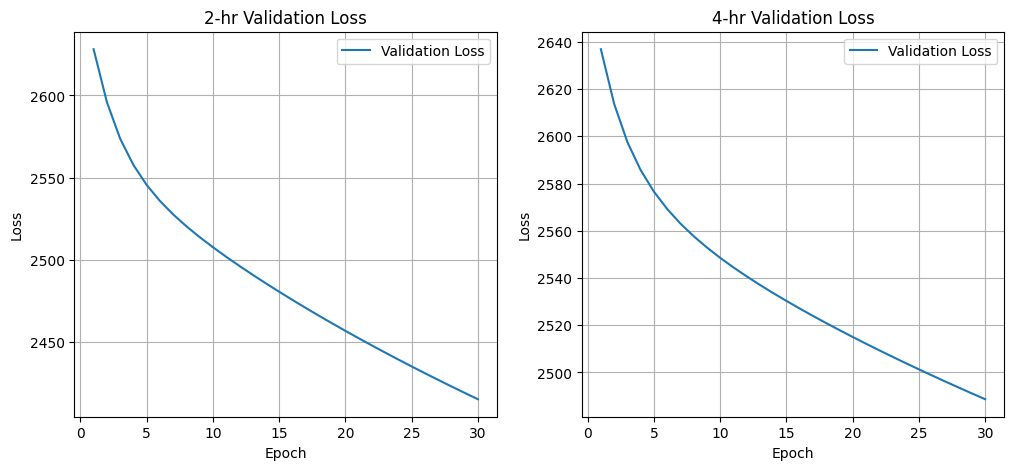

In [95]:
# visual validation loss for 2-hr and 4-hr
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_p, two_p_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-hr Validation Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs_p, four_p_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-hr Validation Loss")
plt.legend()
plt.grid()

plt.show()

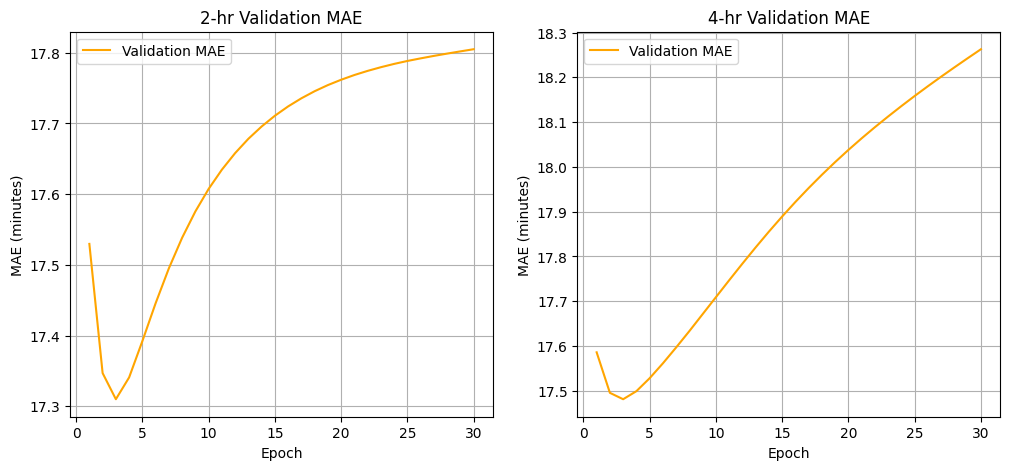

In [96]:
# visual validation mae for 2-hr and 4-hr
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_p, two_p_history.history["val_mae"], label="Validation MAE", color="orange")
plt.xlabel("Epoch")
plt.ylabel("MAE (minutes)")
plt.title("2-hr Validation MAE")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs_p, four_p_history.history["val_mae"], label="Validation MAE", color="orange")
plt.xlabel("Epoch")
plt.ylabel("MAE (minutes)")
plt.title("4-hr Validation MAE")
plt.legend()
plt.grid()

plt.show()

# Parquet Classification Model

## 2-hour classification model

In [98]:
# let's get the features for our classification model with cancelled flights included into category 5
# let's again work with only the numeric features of the parquet dataset
two_p_X_train_cl = two_p_train_df[numeric_features_p]
two_p_y_train_cl = two_p_train_df[cl_target_p]
two_p_X_val_cl = two_p_val_df[numeric_features_p]
two_p_y_val_cl = two_p_val_df[cl_target_p]
two_p_X_test_cl = two_p_test_df[numeric_features_p]
two_p_y_test_cl = two_p_test_df[cl_target_p]

In [99]:
# impute missing values using median from training data
two_p_cl_imputer = SimpleImputer(strategy="median") # use median
two_p_X_train_cl_imp = two_p_cl_imputer.fit_transform(two_p_X_train_cl) # fit the values using the training data median
two_p_X_val_cl_imp = two_p_cl_imputer.transform(two_p_X_val_cl) # impute the training data into val
two_p_X_test_cl_imp = two_p_cl_imputer.transform(two_p_X_test_cl) # impute training data into test

# scale the features based on impute
two_p_cl_scaler = StandardScaler() # build the scaler
two_p_cl_scaler.fit(two_p_X_train_cl_imp) # use the imputed training data for normalization
two_p_X_train_cl_std = two_p_cl_scaler.transform(two_p_X_train_cl_imp) # normalize train
two_p_X_val_cl_std = two_p_cl_scaler.transform(two_p_X_val_cl_imp) # normalize val
two_p_X_test_cl_std = two_p_cl_scaler.transform(two_p_X_test_cl_imp) # normalize test

In [100]:
# pasting in our build_classifier function from the old code
def build_classifier(num_features, num_classes, learning_rate): # function to use for classification model
    tf.keras.backend.clear_session() # start fresh
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [101]:
# build the 2-hour classification model and train the model
two_p_classifier = build_classifier(num_features=two_p_X_train_cl_std.shape[1], num_classes=6, learning_rate=0.01)
two_p_cl_history = two_p_classifier.fit(
    two_p_X_train_cl_std, two_p_y_train_cl,
    validation_data=(two_p_X_val_cl_std, two_p_y_val_cl),
    epochs=30, batch_size=256
)

Epoch 1/30
   1/1164 ━━━━━━━━━━━━━━━━━━━━ 5:13 270ms/step - accuracy: 0.1406 - loss: 2.4118

2026-07-26 09:32:15.071961: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7794 - loss: 0.7207 - val_accuracy: 0.8161 - val_loss: 0.6011
Epoch 2/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7940 - loss: 0.6390 - val_accuracy: 0.8159 - val_loss: 0.5992
Epoch 3/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7941 - loss: 0.6385 - val_accuracy: 0.8159 - val_loss: 0.5993
Epoch 4/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7942 - loss: 0.6384 - val_accuracy: 0.8158 - val_loss: 0.5997
Epoch 5/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7942 - loss: 0.6383 - val_accuracy: 0.8159 - val_loss: 0.5996
Epoch 6/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7942 - loss: 0.6382 - val_accuracy: 0.8159 - val_loss: 0.5998
Epoch 7/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7942 - loss: 0.6382 - val_accuracy: 0.8158 - val_loss: 0.5999
Epoch 8/30
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7942 - loss: 0.6381 - val_accurac

### note on 2-hour classification results:
Validation accuracy of model sits around 81%, but the majority class in our data 'category 0' makes up about 78% of our data. The model does improve just guessing category 0, but only about by 3%.

In [102]:
# what is the accuracy of the model
two_p_test_loss_cl, two_p_test_acc_cl = two_p_classifier.evaluate(two_p_X_test_cl_std, two_p_y_test_cl)
print(f"2-hr Test Accuracy: {two_p_test_acc_cl:.4f}")

1443/1443 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7839 - loss: 0.6603
2-hr Test Accuracy: 0.7839


### the accuracy on the test data is about the same as predicting the majority class

## 4-hour classification model parquet

In [ ]:
# extract features and target for 4-hr classification
four_p_X_train_cl = four_p_train_df[numeric_features_p]
four_p_y_train_cl = four_p_train_df[cl_target_p]
four_p_X_val_cl = four_p_val_df[numeric_features_p]
four_p_y_val_cl = four_p_val_df[cl_target_p]
four_p_X_test_cl = four_p_test_df[numeric_features_p]
four_p_y_test_cl = four_p_test_df[cl_target_p]

In [104]:
# impute and scale
four_p_cl_imputer = SimpleImputer(strategy="median")
four_p_X_train_cl_imp = four_p_cl_imputer.fit_transform(four_p_X_train_cl)
four_p_X_val_cl_imp = four_p_cl_imputer.transform(four_p_X_val_cl)
four_p_X_test_cl_imp = four_p_cl_imputer.transform(four_p_X_test_cl)

four_p_cl_scaler = StandardScaler()
four_p_cl_scaler.fit(four_p_X_train_cl_imp)
four_p_X_train_cl_std = four_p_cl_scaler.transform(four_p_X_train_cl_imp)
four_p_X_val_cl_std = four_p_cl_scaler.transform(four_p_X_val_cl_imp)
four_p_X_test_cl_std = four_p_cl_scaler.transform(four_p_X_test_cl_imp)

In [ ]:
# build and train the 4-hour classification model
four_p_classifier = build_classifier(num_features=four_p_X_train_cl_std.shape[1], num_classes=6, learning_rate=0.01)
four_p_cl_history = four_p_classifier.fit(
    four_p_X_train_cl_std, four_p_y_train_cl,
    validation_data=(four_p_X_val_cl_std, four_p_y_val_cl),
    epochs=20, batch_size=256
)
four_p_test_loss_cl, four_p_test_acc_cl = four_p_classifier.evaluate(four_p_X_test_cl_std, four_p_y_test_cl)
print(f"4-hr Test Accuracy: {four_p_test_acc_cl:.4f}")

Epoch 1/20
   1/1164 ━━━━━━━━━━━━━━━━━━━━ 5:05 263ms/step - accuracy: 0.1406 - loss: 2.4351

2026-07-26 09:41:47.866520: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1164/1164 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7660 - loss: 0.7714 - val_accuracy: 0.8029 - val_loss: 0.6550
Epoch 2/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7818 - loss: 0.6919 - val_accuracy: 0.8028 - val_loss: 0.6532
Epoch 3/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7818 - loss: 0.6915 - val_accuracy: 0.8028 - val_loss: 0.6530
Epoch 4/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7819 - loss: 0.6914 - val_accuracy: 0.8029 - val_loss: 0.6529
Epoch 5/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7819 - loss: 0.6914 - val_accuracy: 0.8029 - val_loss: 0.6529
Epoch 6/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7819 - loss: 0.6913 - val_accuracy: 0.8029 - val_loss: 0.6528
Epoch 7/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7819 - loss: 0.6912 - val_accuracy: 0.8029 - val_loss: 0.6527
Epoch 8/20
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7820 - loss: 0.6911 - val_accurac

### 4-hour classification results
Test accuracy is at 0.7678, which is close to the majority class prediction percentage of 78.25%. 
This model doesn't outperform just guessing 'category 0' that there is under 15 minutes of dealy for the flights.

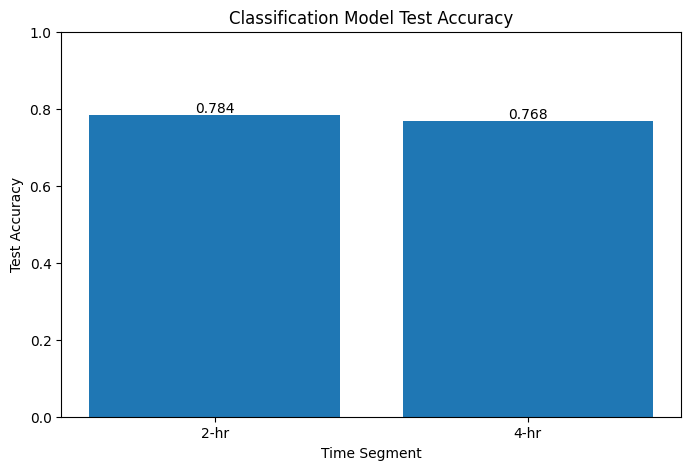

In [113]:
# classification model test accuracy
segments_p = ['2-hr', '4-hr']
nn_test_acc_p = [two_p_test_acc_cl, four_p_test_acc_cl]

plt.figure(figsize=(8,5))
bars1 = plt.bar(segments_p, nn_test_acc_p)
plt.xlabel("Time Segment")
plt.ylabel("Test Accuracy")
plt.title("Classification Model Test Accuracy")
plt.ylim(0, 1)
plt.bar_label(bars1, fmt='%.3f')
plt.show()

## Random Forest Model

In [ ]:
# 2-hr random forest classifier
two_p_forest = RandomForestClassifier(criterion='entropy',
                                       n_estimators=40,
                                       max_depth=10,
                                       random_state=1,
                                       n_jobs=2)
two_p_clf_forest = two_p_forest.fit(two_p_X_train_cl_imp, two_p_y_train_cl)
print('2-hr Accuracy on training data:', two_p_clf_forest.score(two_p_X_train_cl_imp, two_p_y_train_cl))
print('2-hr Accuracy on validation data:', two_p_clf_forest.score(two_p_X_val_cl_imp, two_p_y_val_cl))

2-hr Accuracy on training data: 0.8035318606056536
2-hr Accuracy on validation data: 0.817695726001662


In [109]:
# 4-hr random forest classifier
four_p_forest = RandomForestClassifier(criterion='entropy',
                                        n_estimators=40,
                                        max_depth=10,
                                        random_state=1,
                                        n_jobs=2)
four_p_clf_forest = four_p_forest.fit(four_p_X_train_cl_imp, four_p_y_train_cl)
print('4-hr Accuracy on training data:', four_p_clf_forest.score(four_p_X_train_cl_imp, four_p_y_train_cl))
print('4-hr Accuracy on validation data:', four_p_clf_forest.score(four_p_X_val_cl_imp, four_p_y_val_cl))

4-hr Accuracy on training data: 0.7970187336332505
4-hr Accuracy on validation data: 0.8118790418729


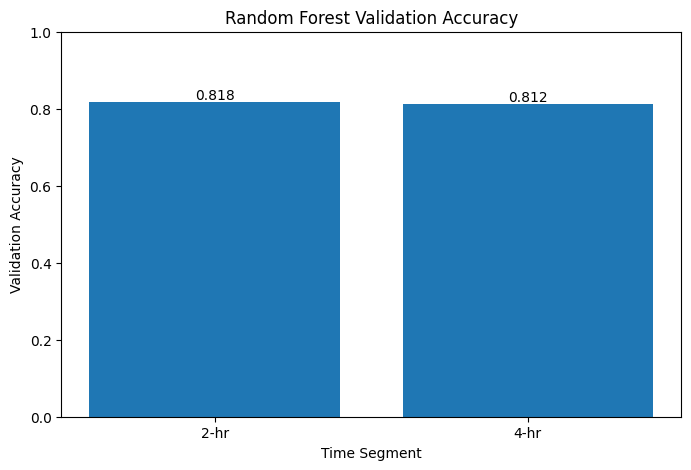

In [112]:
# random forest validation accuracy
rf_val_acc_p = [
    two_p_clf_forest.score(two_p_X_val_cl_imp, two_p_y_val_cl),
    four_p_clf_forest.score(four_p_X_val_cl_imp, four_p_y_val_cl)
]

plt.figure(figsize=(8,5))
bars2 = plt.bar(segments_p, rf_val_acc_p)
plt.xlabel("Time Segment")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Validation Accuracy")
plt.ylim(0, 1)
plt.bar_label(bars2, fmt='%.3f')
plt.show()

In [116]:
# get random forest test accuracy for fair comparison
two_p_rf_test_acc = two_p_clf_forest.score(two_p_X_test_cl_imp, two_p_y_test_cl)
four_p_rf_test_acc = four_p_clf_forest.score(four_p_X_test_cl_imp, four_p_y_test_cl)

print(f"2-hr RF Test Accuracy: {two_p_rf_test_acc:.4f}")
print(f"4-hr RF Test Accuracy: {four_p_rf_test_acc:.4f}")

2-hr RF Test Accuracy: 0.7851
4-hr RF Test Accuracy: 0.7766


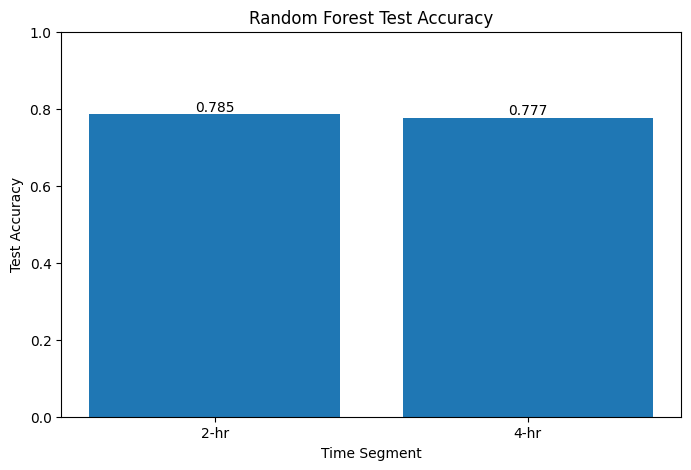

In [117]:
# random forest test accuracy
rf_test_acc_p = [two_p_rf_test_acc, four_p_rf_test_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(segments_p, rf_test_acc_p)
plt.xlabel("Time Segment")
plt.ylabel("Test Accuracy")
plt.title("Random Forest Test Accuracy")
plt.ylim(0, 1)
plt.bar_label(bars, fmt='%.3f')
plt.show()

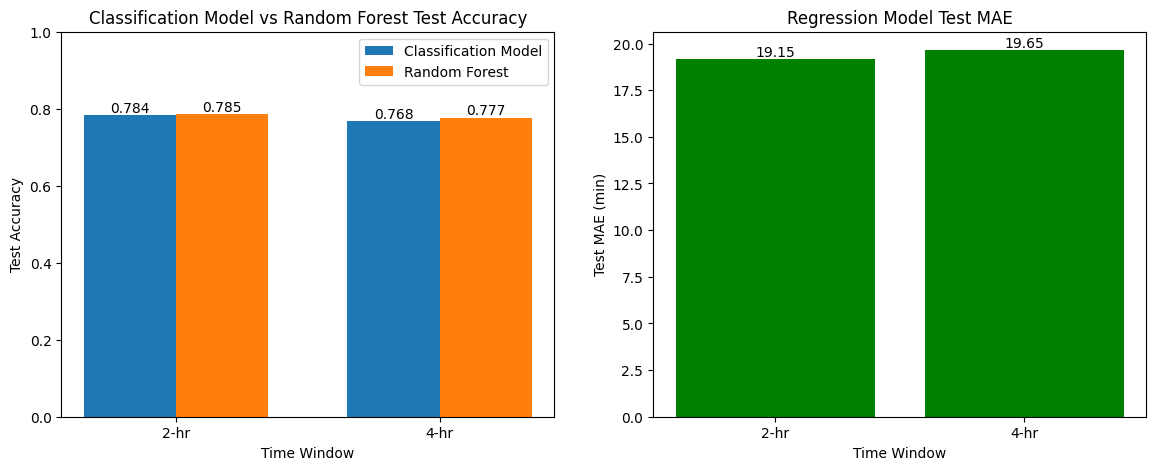

In [119]:
# combined results for classification and random forest test accuracy and regression mae
segments_p = ['2-hr', '4-hr']
nn_test_acc_p = [two_p_test_acc_cl, four_p_test_acc_cl]
rf_test_acc_p = [two_p_rf_test_acc, four_p_rf_test_acc]
reg_mae_p = [two_p_test_mae, four_p_test_mae]

x = np.arange(len(segments_p))
width = 0.35

plt.figure(figsize=(14,5))

# left panel classification vs random forest test accuracy
plt.subplot(1,2,1)
bars1 = plt.bar(x - width/2, nn_test_acc_p, width, label="Classification Model")
bars2 = plt.bar(x + width/2, rf_test_acc_p, width, label="Random Forest")
plt.xticks(x, segments_p)
plt.xlabel("Time Window")
plt.ylabel("Test Accuracy")
plt.title("Classification Model vs Random Forest Test Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.bar_label(bars1, fmt='%.3f')
plt.bar_label(bars2, fmt='%.3f')

# right panel - regression mae
plt.subplot(1,2,2)
bars3 = plt.bar(segments_p, reg_mae_p, color="green")
plt.xlabel("Time Window")
plt.ylabel("Test MAE (min)")
plt.title("Regression Model Test MAE")
plt.bar_label(bars3, fmt='%.2f')

plt.show()

## Parquet Model Summary
Regression model was build to predict the 'dep_delay_minutes' with cancelled flights excluded from the data due to NaN values.
Classification model used six categories to predict delays ('under_15', '15_to_under_60', '60_to_under_120', '120_to_under_240', '240_plus', 'cancelled')

### Results
2-hr: Regression Test Mae (19.15 min) | Baseline MAE (24.17 min) | Classification Test Accuracy (78.4%) | Random Forest Classification Accuracy (78.5%)
4-hr: Regresstion Test Mae (19.65 min) | Baseline MAE (24.17 min) | Classification Test Accuracy (76.8%) | Random Forest Classification Accuracy (77.7%)

Random forest performed about the same as our classification model, with both having around a 76-78% accuracy on the 2-hr and 4-hr models. 
Both model results are very close to the baseline accuracy of guessing at 78% if we predicted each flight would be delayed less than 15 minutes.

# This is the old data analysis using the .csv files, not the parquet files

In [3]:
# load .csv files into data frames
one_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_1h.csv")
twelve_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_12h.csv")

# let's add the 2-hour and 4-hour datasets to perform model work on
two_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_2h.csv")
four_df = pd.read_csv("../Merged_EDA/combined_data/combined_data_4h.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../Merged_EDA/combined_data/combined_data_1h.csv'

In [ ]:
# check shape of both data frames
print("1hr df shape:", one_df.shape)
print("12hr df shape:", twelve_df.shape)

1hr df shape: (334086, 32)
12hr df shape: (346464, 32)


In [ ]:
# check column names
print("one_df columns:\n", one_df.columns.tolist())

one_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [ ]:
# check column names
print("twelve_df columns:\n", twelve_df.columns.tolist())

twelve_df columns:
 ['date', 'scheduled_dep_dt', 'actual_dep_dt', 'carrier_code', 'destination_airport', 'scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'outcome', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'model', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h', 'departure_delay_minutes']


In [ ]:
# lets check the date range for each df
print("1hr date range:", one_df['date'].min(), one_df['date'].max())
print("12hr date range:", twelve_df['date'].min(), twelve_df['date'].max())

1hr date range: 2022-01-01 2026-04-30
12hr date range: 2022-01-01 2026-04-30


In [ ]:
# check for missing values in df
print("one_df missing value count:", one_df.isnull().sum())
print("twellve_df missing value count:", twelve_df.isnull().sum())

one_df missing value count: date                              0
scheduled_dep_dt                  0
actual_dep_dt                     0
carrier_code                      0
destination_airport               0
scheduled_elapsed_time_minutes    0
year                              0
month                             0
day_of_week                       0
is_weekend                        0
sched_dep_hour                    0
outcome                           0
days_until_holiday                0
days_from_holiday                 0
year_mfr                          0
model                             0
no_seats                          0
visibility                        0
ceiling_height                    0
wind_speed                        0
wind_direction                    0
temperature                       0
dew_point_temperature             0
relative_humidity                 0
altimeter                         0
aircraft_age                      0
week_num                          0


## Split the data into Train/Validation/Test

We will use a split as follows\
Train: 2022-01-01 to 2024-12-31\
Validate: 2025-01-01 to 2025-12-31\
Test: 2026-01-01 to 2026-04-03

In [ ]:
# 1-hour data
one_train_df = one_df[
    (one_df['date'] >= "2022-01-01") &
    (one_df['date'] <= "2024-12-31")
]
one_val_df = one_df[
    (one_df['date'] >= "2025-01-01") &
    (one_df['date'] <= "2025-12-31")
]
one_test_df = one_df[
    (one_df['date'] >= "2026-01-01") &
    (one_df['date'] <= "2026-04-30")
]

In [ ]:
print("1-hr. train shape:", one_train_df.shape)
print("1-hr. val shape:", one_val_df.shape)
print("1-hr. test shape:", one_test_df.shape)

1-hr. train shape: (236106, 32)
1-hr. val shape: (81325, 32)
1-hr. test shape: (16655, 32)


In [ ]:
# 12-hour data
twelve_train_df = twelve_df[
    (twelve_df['date'] >= "2022-01-01") &
    (twelve_df['date'] <= "2024-12-31")
]
twelve_val_df = twelve_df[
    (twelve_df['date'] >= "2025-01-01") &
    (twelve_df['date'] <= "2025-12-31")
]
twelve_test_df = twelve_df[
    (twelve_df['date'] >= "2026-01-01") &
    (twelve_df['date'] <= "2026-04-30")
]

In [ ]:
print("12-hour train shape:", twelve_train_df.shape)
print("12-hour val shape:", twelve_val_df.shape)
print("12-hour test shape:", twelve_test_df.shape)

12-hour train shape: (245694, 32)
12-hour val shape: (83399, 32)
12-hour test shape: (17371, 32)


## Feature selection (simple style) & X-y split

In [ ]:
# numeric only feature selection
features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h",
]

target = "departure_delay_minutes"

In [ ]:
# separate train/val/test with features and target variables for X, y
## for one_df
one_X_train = one_train_df[features]
one_y_train = one_train_df[target]

one_X_val = one_val_df[features]
one_y_val = one_val_df[target]

one_X_test = one_test_df[features]
one_y_test = one_test_df[target]

## for twelve_df
twelve_X_train = twelve_train_df[features]
twelve_y_train = twelve_train_df[target]

twelve_X_val = twelve_val_df[features]
twelve_y_val = twelve_val_df[target]

twelve_X_test = twelve_test_df[features]
twelve_y_test = twelve_test_df[target]

## Scale features for optimal performance

In [ ]:
# one hour transforms
# get scaler
one_scaler = StandardScaler()
one_scaler.fit(one_X_train)
# scale one
one_X_train_std = one_scaler.transform(one_X_train)
one_X_val_std = one_scaler.transform(one_X_val)
one_X_test_std = one_scaler.transform(one_X_test)

# twelve hour transforms
# get scaler
twelve_scaler = StandardScaler()
twelve_scaler.fit(twelve_X_train)
# scale twelve
twelve_X_train_std = twelve_scaler.transform(twelve_X_train)
twelve_X_val_std = twelve_scaler.transform(twelve_X_val)
twelve_X_test_std = twelve_scaler.transform(twelve_X_test)

In [ ]:
print("1hr train mean for first 5:", one_X_train_std.mean(axis=0)[:5])
print("1hr train std for first 5: ", one_X_train_std.std(axis=0)[:5])
print("12hr train mean for first 5:", twelve_X_train_std.mean(axis=0)[:5])
print("12hr train std for first 5:", twelve_X_train_std.std(axis=0)[:5])

1hr train mean for first 5: [-4.47802085e-17  9.47992199e-15  1.54082438e-16 -1.92603047e-16
  9.72645389e-17]
1hr train std for first 5:  [1. 1. 1. 1. 1.]
12hr train mean for first 5: [-1.20537828e-16  1.45922494e-14 -1.33262551e-16 -1.58480638e-16
 -1.80459705e-17]
12hr train std for first 5: [1. 1. 1. 1. 1.]


## Baseline Linear Regression Model

In [ ]:
# build regression model with single dense layer
def build_model(num_features, learning_rate):
    tf.keras.backend.clear_session() # reset model
    tf.random.set_seed(0) # reproducible seed

    # build the model
    model = tf.keras.Sequential([ 
        tf.keras.Input(shape=(num_features,)), # use features for input, define how many
        tf.keras.layers.Dense(units=1, use_bias=True) # output single number
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) # use the Adam optimizer

    # use Adam for weight optimization, MSE for prediction error
    model.compile( 
        optimizer=optimizer,
        loss="mse", # compute loss as mean squared error
        metrics=["mae"] # convert MSE back into minutes
    )

    return model

In [ ]:
# build model for both 1-hr and 12-hr data
one_model = build_model(one_X_train_std.shape[1], learning_rate=0.001)
twelve_model = build_model(twelve_X_train_std.shape[1], learning_rate=0.001)

2026-07-15 19:36:25.745199: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-15 19:36:25.745584: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-15 19:36:25.745589: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-15 19:36:25.745766: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-15 19:36:25.745775: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
# confirmn model
one_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Models (1-hour and 12-hour)

In [ ]:
# train models
one_history = one_model.fit(
    one_X_train_std,
    one_y_train,
    validation_data=(one_X_val_std, one_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
  1/923 ━━━━━━━━━━━━━━━━━━━━ 4:32 296ms/step - loss: 1297.0027 - mae: 15.0742

2026-07-15 19:36:26.099601: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-07-15 19:36:26.102098: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1684.1639 - mae: 16.2936 - val_loss: 1729.2389 - val_mae: 17.1713
Epoch 2/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1653.0046 - mae: 16.3990 - val_loss: 1698.9673 - val_mae: 17.7759
Epoch 3/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1632.0386 - mae: 16.5926 - val_loss: 1682.3961 - val_mae: 18.3183
Epoch 4/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1615.8635 - mae: 16.7941 - val_loss: 1672.7997 - val_mae: 18.8072
Epoch 5/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.5679 - mae: 17.0032 - val_loss: 1667.1414 - val_mae: 19.2605
Epoch 6/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1591.3890 - mae: 17.2245 - val_loss: 1663.9724 - val_mae: 19.6894
Epoch 7/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1581.9763 - mae: 17.4598 - val_loss: 1662.5476 - val_mae: 20.1006
Epoch 8/30
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1574.1317 - mae: 17.7079 - val_loss: 1662.4447 - val_mae: 20.4965
Epo

1-hour results: 

predictions on 1-hour training are off by about 19.65 minutes,   
while applied to the validation data off by about 22.78 minutes

In [ ]:
# twelve hour train
twelve_history = twelve_model.fit(
    twelve_X_train_std, twelve_y_train,
    validation_data=(twelve_X_val_std, twelve_y_val),
    epochs=30,
    batch_size=256
)

Epoch 1/30
 16/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1944.8613 - mae: 15.6380    

2026-07-15 19:38:17.500380: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1695.7758 - mae: 16.4380 - val_loss: 1691.3618 - val_mae: 17.4058
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1669.9603 - mae: 16.5301 - val_loss: 1669.6455 - val_mae: 18.0084
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1650.8710 - mae: 16.7173 - val_loss: 1656.3625 - val_mae: 18.5845
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1635.5120 - mae: 16.9376 - val_loss: 1648.2667 - val_mae: 19.1305
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1622.7109 - mae: 17.1791 - val_loss: 1643.6523 - val_mae: 19.6504
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1611.9443 - mae: 17.4385 - val_loss: 1641.5424 - val_mae: 20.1474
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.9392 - mae: 17.7128 - val_loss: 1641.3282 - val_mae: 20.6238
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1595.5260 - mae: 17.9977 - val_loss: 1642.5831 - val_mae: 21.0787
Epo

Results for 12-hour:  
Training is off about 20.05 minutes,  
Validation is off by 23.69 minutes.
*validation lowest at epoch 6 for 19.53 minutes and training of 17.16 minutes

### Train and Validation Performance Plots

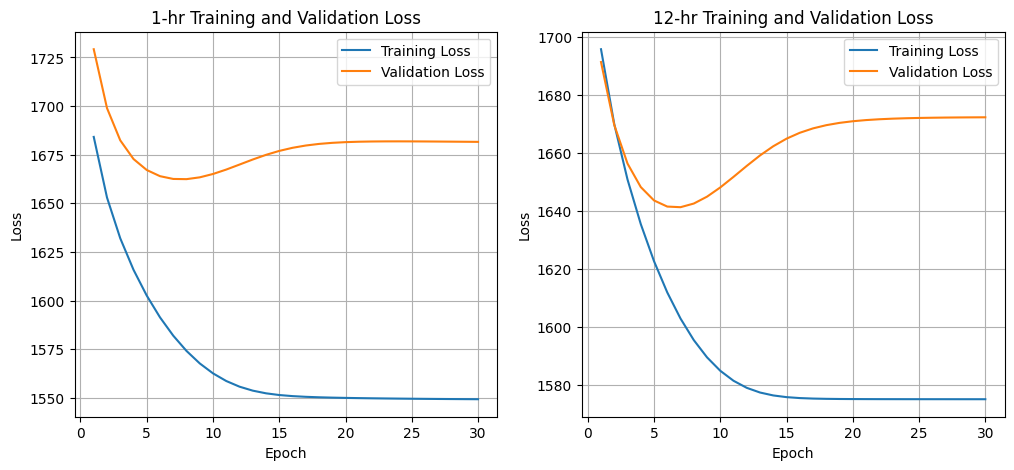

In [ ]:
# get axis parameters
num_epochs = len(one_history.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# plot one_hour
plt.subplot(1,2,1)
plt.plot(epochs, one_history.history["loss"], label="Training Loss")
plt.plot(epochs, one_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1-hr Training and Validation Loss")
plt.legend()
plt.grid()

# plot twelve hour model
plt.subplot(1,2,2)
plt.plot(epochs, twelve_history.history["loss"], label="Training Loss")
plt.plot(epochs, twelve_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("12-hr Training and Validation Loss")
plt.legend()
plt.grid()

### Evaluate Baseline Model Results

In [ ]:
# run trained model on dataset and evaluate performance
one_test_loss, one_test_mae = one_model.evaluate(one_X_test_std, one_y_test)
twelve_test_loss, twelve_test_mae = twelve_model.evaluate(twelve_X_test_std, twelve_y_test)
# print out performance results
print(f"1-hr test loss MSE: {one_test_loss:.4f}, test MAE: {one_test_mae}")
print(f"12-hr test loss MSE: {twelve_test_loss:.4f}, test MAE: {twelve_test_mae}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1563.8066 - mae: 24.1851
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1601.4827 - mae: 25.2504
1-hr test loss MSE: 1563.8066, test MAE: 24.185056686401367
12-hr test loss MSE: 1601.4827, test MAE: 25.25038719177246


## Classification Model

### 1-hour model

In [ ]:
cl_target = "outcome" # use outcome to predict 9 categories of delay

# split data into train, val, and test
# use same feature set as regression model
one_X_train_cl = one_train_df[features]
one_y_train_cl = one_train_df[cl_target]
one_X_val_cl = one_val_df[features]
one_y_val_cl = one_val_df[cl_target]
one_X_test_cl = one_test_df[features]
one_y_test_cl = one_test_df[cl_target]

# scale the train, val, test data
one_X_train_cl_std = one_scaler.transform(one_X_train_cl)
one_X_val_cl_std = one_scaler.transform(one_X_val_cl)
one_X_test_cl_std = one_scaler.transform(one_X_test_cl)

### build classfication model

In [ ]:
def build_classifier(num_features, num_classes, learning_rate): # function to use for classification model
    tf.keras.backend.clear_session() # start fresh
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(num_features,)),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### train classification model

In [ ]:
one_classifier = build_classifier(
    num_features= one_X_train_cl_std.shape[1], 
    num_classes= 9, 
    learning_rate=0.01)

one_cl_history = one_classifier.fit(
    one_X_train_cl_std,
    one_y_train_cl,
    validation_data=(one_X_val_cl_std, one_y_val_cl),
    epochs=20,
    batch_size=256
)

Epoch 1/20
  1/923 ━━━━━━━━━━━━━━━━━━━━ 3:35 234ms/step - accuracy: 0.1328 - loss: 2.8589

2026-07-15 19:40:14.675943: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


923/923 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5874 - loss: 1.0300 - val_accuracy: 0.6303 - val_loss: 0.8973
Epoch 2/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6048 - loss: 0.9030 - val_accuracy: 0.6317 - val_loss: 0.8941
Epoch 3/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6320 - val_loss: 0.8937
Epoch 4/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9020 - val_accuracy: 0.6320 - val_loss: 0.8937
Epoch 5/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6320 - val_loss: 0.8938
Epoch 6/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6049 - loss: 0.9021 - val_accuracy: 0.6319 - val_loss: 0.8938
Epoch 7/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6318 - val_loss: 0.8939
Epoch 8/20
923/923 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6050 - loss: 0.9021 - val_accuracy: 0.6317 - val_

### 12-hour classification model

In [ ]:
# split data into train, val, and test
# use same feature set as regression model
twelve_X_train_cl = twelve_train_df[features]
twelve_y_train_cl = twelve_train_df[cl_target]
twelve_X_val_cl = twelve_val_df[features]
twelve_y_val_cl = twelve_val_df[cl_target]
twelve_X_test_cl = twelve_test_df[features]
twelve_y_test_cl = twelve_test_df[cl_target]

# scale the train, val, test data
twelve_X_train_cl_std = twelve_scaler.transform(twelve_X_train_cl)
twelve_X_val_cl_std = twelve_scaler.transform(twelve_X_val_cl)
twelve_X_test_cl_std = twelve_scaler.transform(twelve_X_test_cl)

In [ ]:
twelve_classifier = build_classifier(
    num_features=twelve_X_train_cl_std.shape[1], 
    num_classes=9, 
    learning_rate=0.01)

twelve_cl_history = twelve_classifier.fit(
    twelve_X_train_cl_std, twelve_y_train_cl,
    validation_data=(twelve_X_val_cl_std, twelve_y_val_cl),
    epochs=20, batch_size=256
)

Epoch 1/20
  1/960 ━━━━━━━━━━━━━━━━━━━━ 3:25 214ms/step - accuracy: 0.1055 - loss: 2.7488

2026-07-15 19:41:39.283533: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5806 - loss: 1.0352 - val_accuracy: 0.6295 - val_loss: 0.9129
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5987 - loss: 0.9158 - val_accuracy: 0.6296 - val_loss: 0.9109
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5987 - loss: 0.9152 - val_accuracy: 0.6295 - val_loss: 0.9110
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5986 - loss: 0.9152 - val_accuracy: 0.6293 - val_loss: 0.9112
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5985 - loss: 0.9152 - val_accuracy: 0.6292 - val_loss: 0.9113
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5985 - loss: 0.9152 - val_accuracy: 0.6291 - val_loss: 0.9113
Epoch 7/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6291 - val_loss: 0.9114
Epoch 8/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9152 - val_accuracy: 0.6291 - val_

In [ ]:
# evaluate both models
one_test_loss, one_test_acc = one_classifier.evaluate(one_X_test_cl_std, one_y_test_cl)
twelve_test_loss, twelve_test_acc = twelve_classifier.evaluate(twelve_X_test_cl_std, twelve_y_test_cl)

print(f"1hr  Test Loss: {one_test_loss:.4f} | Test Accuracy: {one_test_acc:.4f}")
print(f"12hr Test Loss: {twelve_test_loss:.4f} | Test Accuracy: {twelve_test_acc:.4f}")

 28/521 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5235 - loss: 1.1071

2026-07-15 19:43:07.816163: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6130 - loss: 0.9219
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5943 - loss: 0.9668
1hr  Test Loss: 0.9219 | Test Accuracy: 0.6130
12hr Test Loss: 0.9668 | Test Accuracy: 0.5943


Classification results:  
1-hr: test loss = 0.92, test accuracy: 0.61  
12-hr: test loss = 0.96, test accuracy: 0.59

The 1 hour model has a lower loss of 0.9219 vs. 0.9668, meaning the 1-hr model is more confident in its predictions.
The 1-hour model also has a better accuracy predicting delays, at 61.30% vs. the 12-hour 59.43%

## Repeat for 2-hour and 4-hour datasets

In [ ]:
# check shape of new df
print("2hr data shape:", two_df.shape)
print("4hr data shape:", four_df.shape)

2hr data shape: (335918, 32)
4hr data shape: (339996, 32)


In [ ]:
# check the date range of these new dfs
print("2hr date range:", two_df['date'].min(), two_df["date"].max())
print("4hr date range:", four_df['date'].min(), four_df["date"].max())

2hr date range: 2022-01-01 2026-04-30
4hr date range: 2022-01-01 2026-04-30


## split the df into train/val/test

In [ ]:
# 2-hour data
two_train_df = two_df[
    (two_df['date'] >= "2022-01-01") &
    (two_df['date'] <= "2024-12-31")
]
two_val_df = two_df[
    (two_df['date'] >= "2025-01-01") &
    (two_df['date'] <= "2025-12-31")
]
two_test_df = two_df[
    (two_df['date'] >= "2026-01-01") &
    (two_df['date'] <= "2026-04-30")
]

In [ ]:
# 4-hour data
four_train_df = four_df[
    (four_df['date'] >= "2022-01-01") &
    (four_df['date'] <= "2024-12-31")
]
four_val_df = four_df[
    (four_df['date'] >= "2025-01-01") &
    (four_df['date'] <= "2025-12-31")
]
four_test_df = four_df[
    (four_df['date'] >= "2026-01-01") &
    (four_df['date'] <= "2026-04-30")
]

In [ ]:
# validate the 2-hour split
print("2-hr. train shape:", two_train_df.shape)
print("2-hr. val shape:", two_val_df.shape)
print("2-hr. test shape:", two_test_df.shape)

2-hr. train shape: (236894, 32)
2-hr. val shape: (82202, 32)
2-hr. test shape: (16822, 32)


In [ ]:
# validate the 4-hours split
print("4-hr. train shape:", four_train_df.shape)
print("4-hr. val shape:", four_val_df.shape)
print("4-hr. test shape:", four_test_df.shape)

4-hr. train shape: (240324, 32)
4-hr. val shape: (82785, 32)
4-hr. test shape: (16887, 32)


## Build regression model for 2-hour and 4-hour

In [ ]:
# 2-hour train/val/test
two_X_train = two_train_df[features]
two_y_train = two_train_df[target]
two_X_val = two_val_df[features]
two_y_val = two_val_df[target]
two_X_test = two_test_df[features]
two_y_test = two_test_df[target]

# 4-hour data train/val/test
four_X_train = four_train_df[features]
four_y_train = four_train_df[target]
four_X_val = four_val_df[features]
four_y_val = four_val_df[target]
four_X_test = four_test_df[features]
four_y_test = four_test_df[target]

### scale the model

In [ ]:
# get scaler for 2-hour
two_scaler = StandardScaler()
two_scaler.fit(two_X_train)

# scale the train, val, test data
two_X_train_std = two_scaler.transform(two_X_train)
two_X_val_std = two_scaler.transform(two_X_val)
two_X_test_std = two_scaler.transform(two_X_test)

# get scaler for 4-hour
four_scaler = StandardScaler()
four_scaler.fit(four_X_train)

# scale the train, val, test data
four_X_train_std = four_scaler.transform(four_X_train)
four_X_val_std = four_scaler.transform(four_X_val)
four_X_test_std = four_scaler.transform(four_X_test)

### build models

In [ ]:
# two hour model
two_model = build_model(num_features=two_X_train_std.shape[1], learning_rate=0.001)
two_history = two_model.fit(
    two_X_train_std, two_y_train,
    validation_data=(two_X_val_std, two_y_val),
    epochs=30, batch_size=256
)

Epoch 1/30
 15/926 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1417.7360 - mae: 15.7163    

2026-07-15 19:44:41.321915: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1694.4452 - mae: 16.4167 - val_loss: 1719.2836 - val_mae: 17.0488
Epoch 2/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1664.1528 - mae: 16.4646 - val_loss: 1685.7698 - val_mae: 17.6107
Epoch 3/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1643.1284 - mae: 16.6185 - val_loss: 1666.9318 - val_mae: 18.1761
Epoch 4/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1626.8567 - mae: 16.8081 - val_loss: 1656.0757 - val_mae: 18.7182
Epoch 5/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1613.6200 - mae: 17.0203 - val_loss: 1649.9766 - val_mae: 19.2295
Epoch 6/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1602.6411 - mae: 17.2512 - val_loss: 1646.9331 - val_mae: 19.7140
Epoch 7/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1593.5107 - mae: 17.4976 - val_loss: 1645.9855 - val_mae: 20.1743
Epoch 8/30
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1585.9846 - mae: 17.7557 - val_loss: 1646.5522 - val_mae: 20.6116
Epo

In [ ]:
# four hour model
four_model = build_model(num_features=four_X_train_std.shape[1], learning_rate=0.001)
four_history = four_model.fit(
    four_X_train_std, four_y_train,
    validation_data=(four_X_val_std, four_y_val),
    epochs=30, batch_size=256
)

Epoch 1/30
 16/939 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2199.8993 - mae: 17.3786    

2026-07-15 19:47:23.389536: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1697.5826 - mae: 16.4735 - val_loss: 1716.4081 - val_mae: 17.0495
Epoch 2/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1661.9175 - mae: 16.3903 - val_loss: 1681.6217 - val_mae: 17.6841
Epoch 3/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1639.5760 - mae: 16.5496 - val_loss: 1663.0375 - val_mae: 18.2955
Epoch 4/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1622.8185 - mae: 16.7513 - val_loss: 1652.5593 - val_mae: 18.8551
Epoch 5/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1609.2981 - mae: 16.9713 - val_loss: 1646.7760 - val_mae: 19.3738
Epoch 6/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1598.1567 - mae: 17.2090 - val_loss: 1644.0209 - val_mae: 19.8615
Epoch 7/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1588.9684 - mae: 17.4632 - val_loss: 1643.3690 - val_mae: 20.3232
Epoch 8/30
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1581.4656 - mae: 17.7289 - val_loss: 1644.2422 - val_mae: 20.7615
Epo

### baseline model comparison

In [ ]:
# how do all of our models compare
one_test_loss, one_test_mae = one_model.evaluate(one_X_test_std, one_y_test)
twelve_test_loss, twelve_test_mae = twelve_model.evaluate(twelve_X_test_std, twelve_y_test)
two_test_loss, two_test_mae = two_model.evaluate(two_X_test_std, two_y_test)
four_test_loss, four_test_mae = four_model.evaluate(four_X_test_std, four_y_test)

print(f"1-hr  Test MAE: {one_test_mae:.3f}")
print(f"2-hr  Test MAE: {two_test_mae:.3f}")
print(f"4-hr  Test MAE: {four_test_mae:.3f}")
print(f"12-hr Test MAE: {twelve_test_mae:.3f}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1563.8066 - mae: 24.1851
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1601.4827 - mae: 25.2504
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1497.1378 - mae: 24.6680
528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1540.1444 - mae: 24.6849
1-hr  Test MAE: 24.185
2-hr  Test MAE: 24.668
4-hr  Test MAE: 24.685
12-hr Test MAE: 25.250


## classification models 2-hour and 4-hour

In [ ]:
# split data into train, val, and test
# use same feature set as regression model
two_X_train_cl = two_train_df[features]
two_y_train_cl = two_train_df[cl_target]
two_X_val_cl = two_val_df[features]
two_y_val_cl = two_val_df[cl_target]
two_X_test_cl = two_test_df[features]
two_y_test_cl = two_test_df[cl_target]

In [ ]:
# four hour data
four_X_train_cl = four_train_df[features]
four_y_train_cl = four_train_df[cl_target]
four_X_val_cl = four_val_df[features]
four_y_val_cl = four_val_df[cl_target]
four_X_test_cl = four_test_df[features]
four_y_test_cl = four_test_df[cl_target]

In [ ]:
# scale the train, val, test data
two_X_train_cl_std = two_scaler.transform(two_X_train_cl)
two_X_val_cl_std = two_scaler.transform(two_X_val_cl)
two_X_test_cl_std = two_scaler.transform(two_X_test_cl)

four_X_train_cl_std = four_scaler.transform(four_X_train_cl)
four_X_val_cl_std = four_scaler.transform(four_X_val_cl)
four_X_test_cl_std = four_scaler.transform(four_X_test_cl)

In [ ]:
# build two classifier
two_classifier = build_classifier(num_features=two_X_train_cl_std.shape[1], num_classes=9, learning_rate=0.01)
# train the classifier 
two_cl_history = two_classifier.fit(
    two_X_train_cl_std, two_y_train_cl,
    validation_data=(two_X_val_cl_std, two_y_val_cl),
    epochs=20, batch_size=256
)
# build four classifier
four_classifier = build_classifier(num_features=four_X_train_cl_std.shape[1], num_classes=9, learning_rate=0.01)
# trian four classifier
four_cl_history = four_classifier.fit(
    four_X_train_cl_std, four_y_train_cl,
    validation_data=(four_X_val_cl_std, four_y_val_cl),
    epochs=20, batch_size=256
)

Epoch 1/20
 15/926 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1338 - loss: 2.6949    

2026-07-15 19:55:13.935314: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


926/926 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5813 - loss: 1.0331 - val_accuracy: 0.5711 - val_loss: 0.9296
Epoch 2/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9051 - val_accuracy: 0.5700 - val_loss: 0.9269
Epoch 3/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5982 - loss: 0.9043 - val_accuracy: 0.5691 - val_loss: 0.9273
Epoch 4/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9043 - val_accuracy: 0.5681 - val_loss: 0.9278
Epoch 5/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5984 - loss: 0.9043 - val_accuracy: 0.5675 - val_loss: 0.9281
Epoch 6/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5671 - val_loss: 0.9282
Epoch 7/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5670 - val_loss: 0.9282
Epoch 8/20
926/926 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5983 - loss: 0.9044 - val_accuracy: 0.5669 - val_

2026-07-15 19:56:38.697996: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


939/939 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5826 - loss: 1.0270 - val_accuracy: 0.6161 - val_loss: 0.8995
Epoch 2/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5997 - loss: 0.9032 - val_accuracy: 0.6177 - val_loss: 0.8964
Epoch 3/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5996 - loss: 0.9024 - val_accuracy: 0.6187 - val_loss: 0.8958
Epoch 4/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5997 - loss: 0.9024 - val_accuracy: 0.6194 - val_loss: 0.8954
Epoch 5/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9024 - val_accuracy: 0.6197 - val_loss: 0.8952
Epoch 6/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6199 - val_loss: 0.8952
Epoch 7/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6200 - val_loss: 0.8951
Epoch 8/20
939/939 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5998 - loss: 0.9025 - val_accuracy: 0.6201 - val_

In [ ]:
# let's compare the models
one_test_loss_cl, one_test_acc_cl = one_classifier.evaluate(one_X_test_cl_std, one_y_test_cl)
twelve_test_loss_cl, twelve_test_acc_cl = twelve_classifier.evaluate(twelve_X_test_cl_std, twelve_y_test_cl)
two_test_loss_cl, two_test_acc_cl = two_classifier.evaluate(two_X_test_cl_std, two_y_test_cl)
four_test_loss_cl, four_test_acc_cl = four_classifier.evaluate(four_X_test_cl_std, four_y_test_cl)

print(f"1-hr  Test Accuracy: {one_test_acc_cl:.4f}")
print(f"2-hr  Test Accuracy: {two_test_acc_cl:.4f}")
print(f"4-hr  Test Accuracy: {four_test_acc_cl:.4f}")
print(f"12-hr Test Accuracy: {twelve_test_acc_cl:.4f}")

521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6130 - loss: 0.9219
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5943 - loss: 0.9668
526/526 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5272 - loss: 0.9862
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5938 - loss: 0.9272
1-hr  Test Accuracy: 0.6130
2-hr  Test Accuracy: 0.5272
4-hr  Test Accuracy: 0.5938
12-hr Test Accuracy: 0.5943


### loss and accuracy plots for 2-hr and 4-hr regression

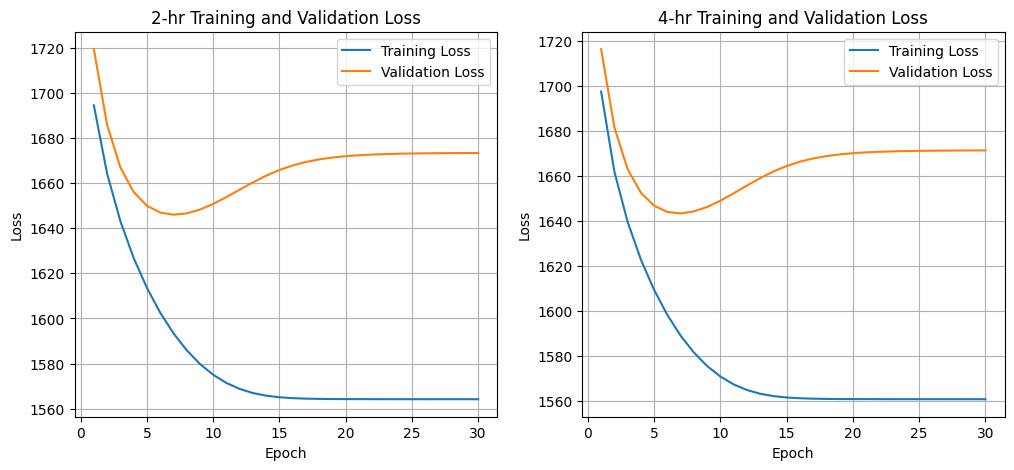

In [ ]:
# plot the 2-hr and 4-hr
# get axis parameters
num_epochs = len(two_history.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# plot two_hour
plt.subplot(1,2,1)
plt.plot(epochs, two_history.history["loss"], label="Training Loss")
plt.plot(epochs, two_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-hr Training and Validation Loss")
plt.legend()
plt.grid()

# plot four_hour
plt.subplot(1,2,2)
plt.plot(epochs, four_history.history["loss"], label="Training Loss")
plt.plot(epochs, four_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-hr Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

### loss and accuracy plots for 2-hr and 4-hr classification

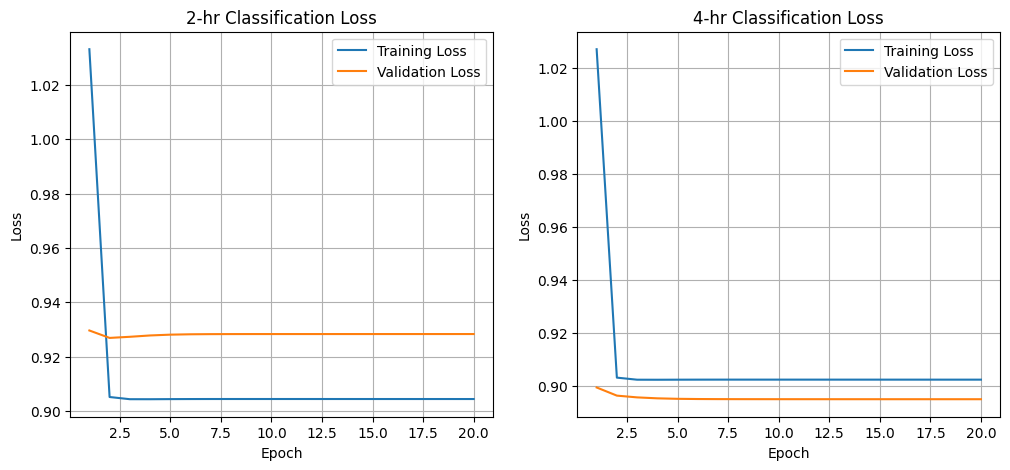

In [ ]:
# get the y-axis loss range
num_epochs_cl = len(two_cl_history.history["loss"])
# get the x-axis epoch range
epochs_cl = range(1, num_epochs_cl + 1)

# create figure for plots
plt.figure(figsize=(12,5))

# plot the 2-hour classification
plt.subplot(1,2,1)
plt.plot(epochs_cl, two_cl_history.history["loss"], label="Training Loss")
plt.plot(epochs_cl, two_cl_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-hr Classification Loss")
plt.legend()
plt.grid()

# plot the 4-hour classification
plt.subplot(1,2,2)
plt.plot(epochs_cl, four_cl_history.history["loss"], label="Training Loss")
plt.plot(epochs_cl, four_cl_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-hr Classification Loss")
plt.legend()
plt.grid()

plt.show()

## Random forest modeling

In [ ]:
# one hour random forest classifier
one_forest = RandomForestClassifier(criterion='entropy',
                                     n_estimators=40,
                                     max_depth=10,
                                     random_state=1,
                                     n_jobs=2)
one_clf_forest = one_forest.fit(one_X_train_cl, one_y_train_cl)
print('1hr Accuracy on training data:', one_clf_forest.score(one_X_train_cl, one_y_train_cl))
print('1hr Accuracy on validation data:', one_clf_forest.score(one_X_val_cl, one_y_val_cl))
print('-'*50)
print('Features:', features)
print('Feature importances:', one_clf_forest.feature_importances_)

1hr Accuracy on training data: 0.6358965888202757
1hr Accuracy on validation data: 0.6508330771595451
--------------------------------------------------
Features: ['scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h']
Feature importances: [0.04878606 0.01709101 0.02264417 0.01472846 0.00463021 0.17708121
 0.03457885 0.02630773 0.02215843 0.05609451 0.00469852 0.03550977
 0.0185343  0.02348234 0.02305253 0.01675059 0.02166151 0.03255644
 0.02327648 0.04692797 0.02158771 0.1516948  0.10489466 0.05127173]


In [ ]:
# two hour random forest classifier
two_forest = RandomForestClassifier(criterion='entropy',
                                     n_estimators=40,
                                     max_depth=10,
                                     random_state=1,
                                     n_jobs=2)
two_clf_forest = two_forest.fit(two_X_train_cl, two_y_train_cl)
print('2hr Accuracy on training data:', two_clf_forest.score(two_X_train_cl, two_y_train_cl))
print('2hr Accuracy on validation data:', two_clf_forest.score(two_X_val_cl, two_y_val_cl))
print('-'*50)
print('Features:', features)
print('Feature importances:', two_clf_forest.feature_importances_)

2hr Accuracy on training data: 0.6342668028738592
2hr Accuracy on validation data: 0.6513588477166006
--------------------------------------------------
Features: ['scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h']
Feature importances: [0.04890597 0.01826301 0.03117727 0.01578242 0.00433145 0.18745266
 0.0355595  0.02844951 0.02247114 0.05913036 0.00653691 0.0338505
 0.01979076 0.02492748 0.02496054 0.0190784  0.02297041 0.03095669
 0.02377296 0.04752806 0.02127879 0.10298426 0.09029819 0.07954277]


In [ ]:
# four hour random forest classifier
four_forest = RandomForestClassifier(criterion='entropy',
                                      n_estimators=40,
                                      max_depth=10,
                                      random_state=1,
                                      n_jobs=2)
four_clf_forest = four_forest.fit(four_X_train_cl, four_y_train_cl)
print('4hr Accuracy on training data:', four_clf_forest.score(four_X_train_cl, four_y_train_cl))
print('4hr Accuracy on validation data:', four_clf_forest.score(four_X_val_cl, four_y_val_cl))
print('-'*50)
print('Features:', features)
print('Feature importances:', four_clf_forest.feature_importances_)

4hr Accuracy on training data: 0.6327416321299579
4hr Accuracy on validation data: 0.6517968230959715
--------------------------------------------------
Features: ['scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h']
Feature importances: [0.05169835 0.02243135 0.02893891 0.0173681  0.00521629 0.18189028
 0.03646175 0.0305116  0.02441617 0.06730545 0.0058412  0.03430295
 0.02033531 0.02654105 0.02703014 0.01940372 0.02664212 0.03431468
 0.02538134 0.05010718 0.02284569 0.05612329 0.07712699 0.10776611]


In [ ]:
# twelve hour random forest classifier
twelve_forest = RandomForestClassifier(criterion='entropy',
                                        n_estimators=40,
                                        max_depth=10,
                                        random_state=1,
                                        n_jobs=2)
twelve_clf_forest = twelve_forest.fit(twelve_X_train_cl, twelve_y_train_cl)
print('12hr Accuracy on training data:', twelve_clf_forest.score(twelve_X_train_cl, twelve_y_train_cl))
print('12hr Accuracy on validation data:', twelve_clf_forest.score(twelve_X_val_cl, twelve_y_val_cl))
print('-'*50)
print('Features:', features)
print('Feature importances:', twelve_clf_forest.feature_importances_)

12hr Accuracy on training data: 0.6296124447483455
12hr Accuracy on validation data: 0.6482571733474023
--------------------------------------------------
Features: ['scheduled_elapsed_time_minutes', 'year', 'month', 'day_of_week', 'is_weekend', 'sched_dep_hour', 'days_until_holiday', 'days_from_holiday', 'year_mfr', 'no_seats', 'visibility', 'ceiling_height', 'wind_speed', 'wind_direction', 'temperature', 'dew_point_temperature', 'relative_humidity', 'altimeter', 'aircraft_age', 'week_num', 'temperature_dewpoint_spread', 'airport_delay_average_1h', 'airport_delay_stddev_1h', 'airport_departures_observed_1h']
Feature importances: [0.05601045 0.02747996 0.02932817 0.0209995  0.00426012 0.26487413
 0.04476231 0.03362305 0.02563738 0.07242043 0.00522246 0.02442121
 0.02697006 0.04667413 0.02308964 0.01969393 0.02366613 0.03564613
 0.02854448 0.05409262 0.02263732 0.04428836 0.03323386 0.03242415]


In [ ]:
# save results to use in plot
one_rf_test_acc = one_clf_forest.score(one_X_test_cl, one_y_test_cl)
two_rf_test_acc = two_clf_forest.score(two_X_test_cl, two_y_test_cl)
four_rf_test_acc = four_clf_forest.score(four_X_test_cl, four_y_test_cl)
twelve_rf_test_acc = twelve_clf_forest.score(twelve_X_test_cl, twelve_y_test_cl)

### random forest accuracy results

In [ ]:
print('1-hr  Test Accuracy:', one_rf_test_acc)
print('2-hr  Test Accuracy:', two_rf_test_acc)
print('4-hr  Test Accuracy:', four_rf_test_acc)
print('12-hr Test Accuracy:', twelve_rf_test_acc)

1-hr  Test Accuracy: 0.6303212248574002
2-hr  Test Accuracy: 0.6342289858518606
4-hr  Test Accuracy: 0.6338011488126961
12-hr Test Accuracy: 0.6106729606815957


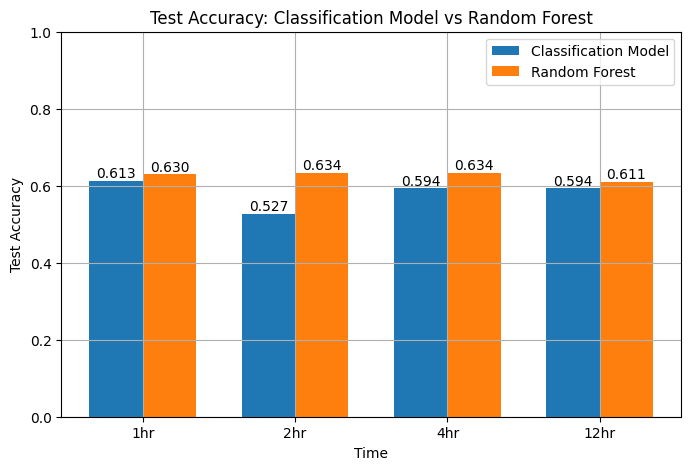

In [ ]:
# plot cl vs rf accuracy
plt.figure(figsize=(8,5))
# separate bars
bars1 = plt.bar(x - width/2, nn_test_acc, width, label='Classification Model')
bars2 = plt.bar(x + width/2, rf_test_acc, width, label='Random Forest')

plt.xlabel('Time')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy: Classification Model vs Random Forest')
plt.xticks(x, segments)
plt.ylim(0, 1) # get the value out of 100%
plt.legend()
plt.grid()

# add accuracy labels above each bar
plt.bar_label(bars1, fmt='%.3f')
plt.bar_label(bars2, fmt='%.3f')

plt.show()

We have 9 categories of delays. 1/9 is ~ 11% accuracy by guessing. Our models are producing around 63% which is better than guessing, but we only get the flight delay prediction right 2/3 times.

In [ ]:
print(one_train_df["outcome"].value_counts(normalize=True))

outcome
0.0    0.600235
1.0    0.334608
2.0    0.039855
3.0    0.012660
4.0    0.005002
8.0    0.002596
5.0    0.002135
7.0    0.001694
6.0    0.001216
Name: proportion, dtype: float64


We are seeing the outcomes on our training dataset are roughly 60% after we normalize the values. This is very close to our rnadom forest models. If our model just predicted outcome '0', for 'no delay', the model would be pretty close to the accuracy of CL and RF models.